In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV
import pickle

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Collab_Datasets./depression_student.csv")

# **Exploring data Analysis (EDA)**

In [ ]:
data.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2,4,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4,5,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1,3,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1,4,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1,5,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [ ]:
data

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2,4,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4,5,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1,3,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1,4,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1,5,More than 8 hours,Healthy,Yes,4,2,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
497,Male,26,5,2,More than 8 hours,Unhealthy,No,8,3,No,Yes
498,Male,24,2,1,Less than 5 hours,Unhealthy,Yes,8,5,No,Yes
499,Female,23,3,5,5-6 hours,Healthy,No,1,5,Yes,No
500,Male,33,4,4,More than 8 hours,Healthy,No,8,1,Yes,No


In [ ]:
data.shape

(502, 11)

In [ ]:
data.dtypes

,0
Gender,object
Age,int64
Academic Pressure,int64
Study Satisfaction,int64
Sleep Duration,object
Dietary Habits,object
Have you ever had suicidal thoughts ?,object
Study Hours,int64
Financial Stress,int64
Family History of Mental Illness,object


In [ ]:
data.nunique()

,0
Gender,2
Age,17
Academic Pressure,5
Study Satisfaction,5
Sleep Duration,4
Dietary Habits,3
Have you ever had suicidal thoughts ?,2
Study Hours,13
Financial Stress,5
Family History of Mental Illness,2


In [ ]:
for col in data:
  print(f"{col}:",data[col].value_counts(),"\n");

Gender: Gender
Male      267
Female    235
Name: count, dtype: int64 

Age: Age
28    39
24    37
20    37
33    36
29    36
34    32
25    29
21    29
30    28
31    27
32    27
27    26
19    26
23    24
18    24
22    23
26    22
Name: count, dtype: int64 

Academic Pressure: Academic Pressure
3    125
1     99
5     98
4     92
2     88
Name: count, dtype: int64 

Study Satisfaction: Study Satisfaction
4    116
3    103
2    100
5     97
1     86
Name: count, dtype: int64 

Sleep Duration: Sleep Duration
7-8 hours            128
More than 8 hours    128
5-6 hours            123
Less than 5 hours    123
Name: count, dtype: int64 

Dietary Habits: Dietary Habits
Moderate     172
Unhealthy    169
Healthy      161
Name: count, dtype: int64 

Have you ever had suicidal thoughts ?: Have you ever had suicidal thoughts ?
Yes    260
No     242
Name: count, dtype: int64 

Study Hours: Study Hours
10    53
12    46
8     45
6     42
11    41
4     38
2     37
3     37
7     36
0     34
9     

In [ ]:
data.isnull().sum()

,0
Gender,0
Age,0
Academic Pressure,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Have you ever had suicidal thoughts ?,0
Study Hours,0
Financial Stress,0
Family History of Mental Illness,0


In [ ]:
data.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Age Distribution')

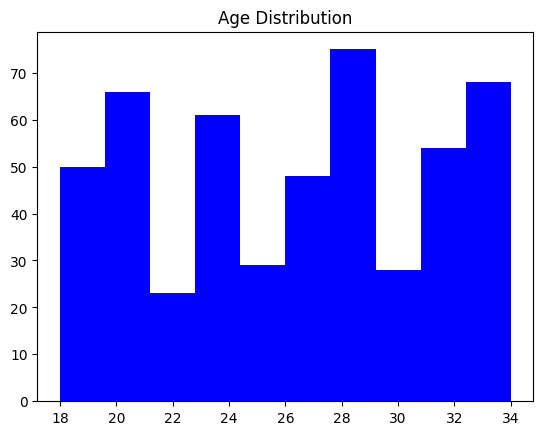

In [ ]:
plt.hist(data['Age'],color='b')
plt.title("Age Distribution")

Text(0.5, 1.0, 'Gender Distribution')

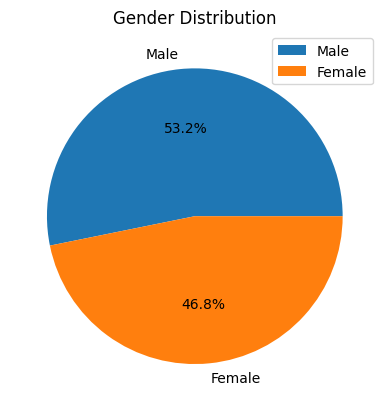

In [ ]:
plt.pie(data['Gender'].value_counts(),labels=data['Gender'].value_counts().index,autopct='%1.1f%%')
plt.legend()
plt.title("Gender Distribution")

Text(0.5, 1.0, 'Depression by gender')

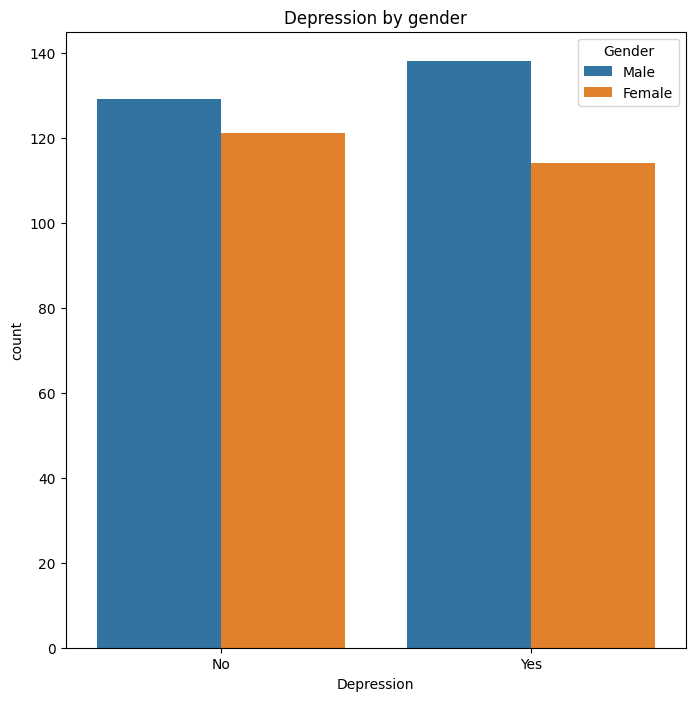

In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(x="Depression",hue="Gender",data=data)
plt.title("Depression by gender")

Text(0.5, 1.0, 'Depression due to Hereditary')

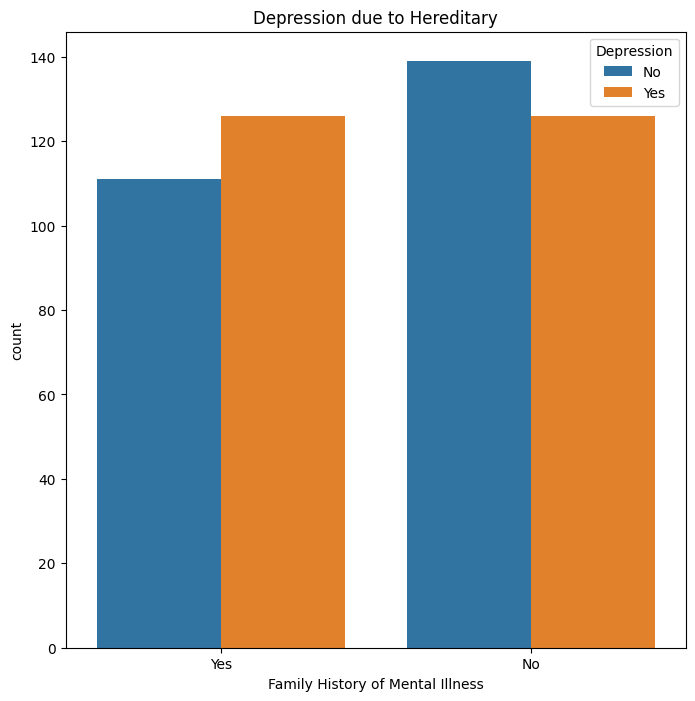

In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(x='Family History of Mental Illness',hue='Depression',data=data)
plt.title("Depression due to Hereditary")

Text(0.5, 1.0, 'Depression by Age')

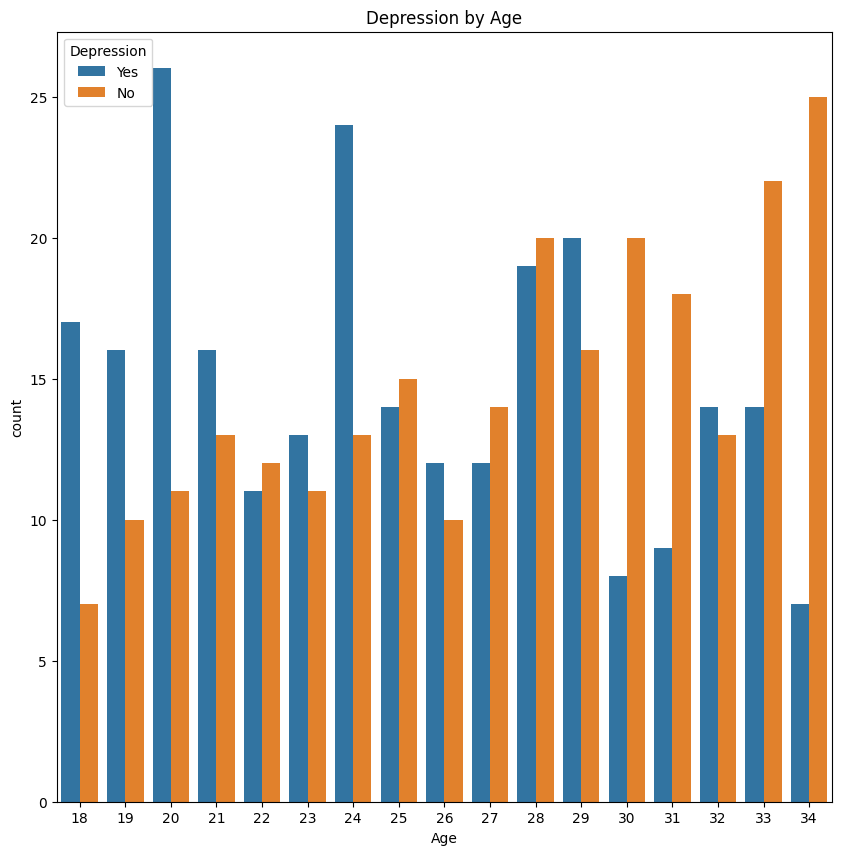

In [ ]:
plt.figure(figsize=(10,10))
sns.countplot(x="Age",hue="Depression",data=data)
plt.title("Depression by Age")

Text(0.5, 1.0, 'Depression due to genes')

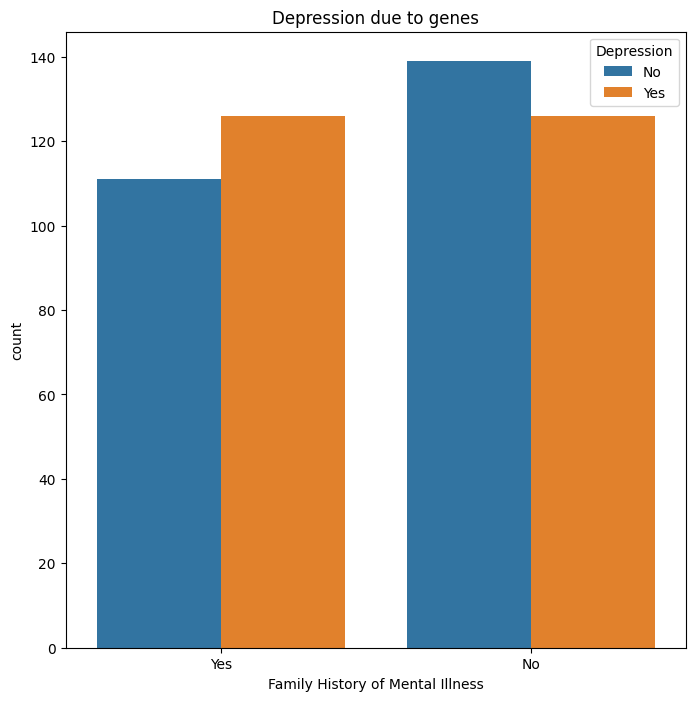

In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(x="Family History of Mental Illness",hue="Depression",data=data)
plt.title("Depression due to genes")

Text(0.5, 1.0, 'Depression by Study Satisfaction')

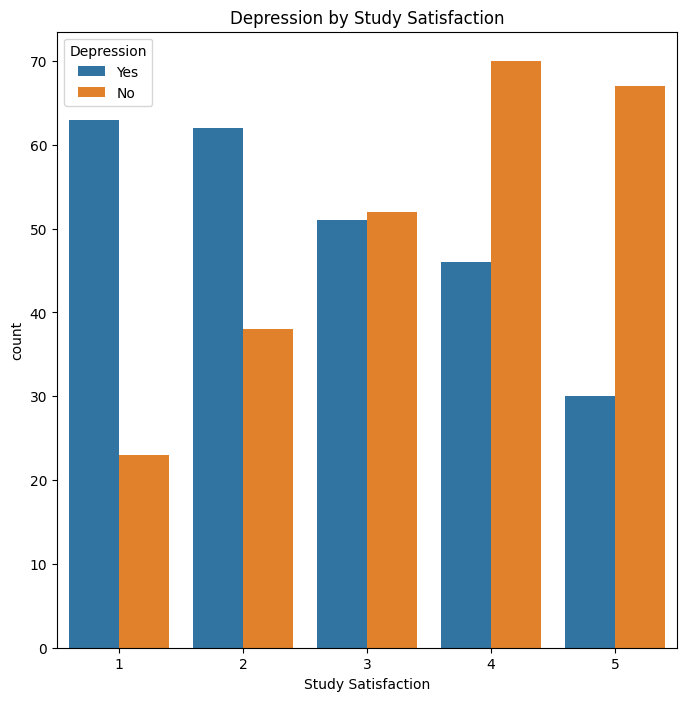

In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(x="Study Satisfaction",hue="Depression",data=data)
plt.title("Depression by Study Satisfaction")

In [ ]:
cols = [
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Depression'
]

for col in cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

In [ ]:
sleep_map={
    'Less than 5 hours':1,
    '5-6 hours':2,
    '7-8 hours':3,
    'More than 8 hours':4
}
data['Sleep Duration']=data['Sleep Duration'].map(sleep_map)

Text(0.5, 1.0, 'Correlation Matrix')

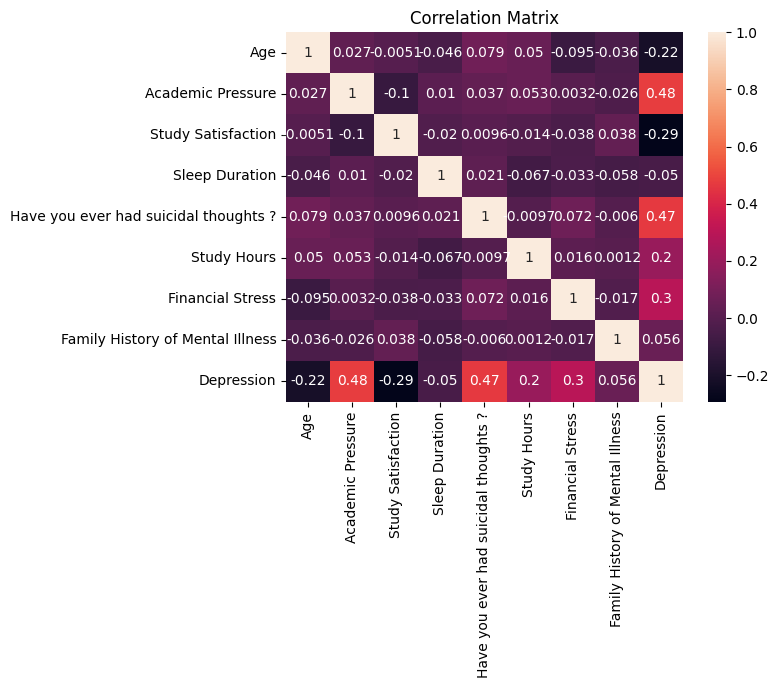

In [ ]:
import seaborn as sns
Num_data=data.select_dtypes(include='number')
sns.heatmap(Num_data.corr(), annot=True)
plt.title("Correlation Matrix")

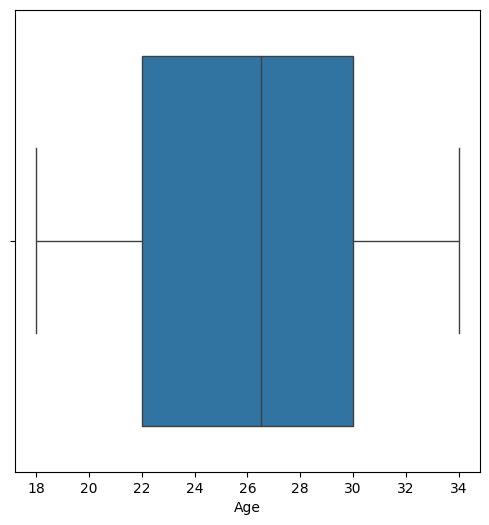

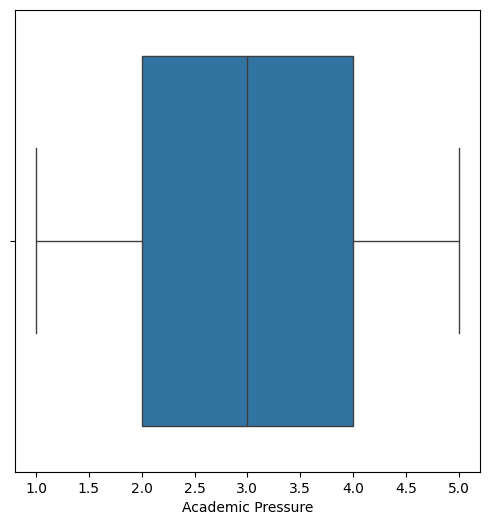

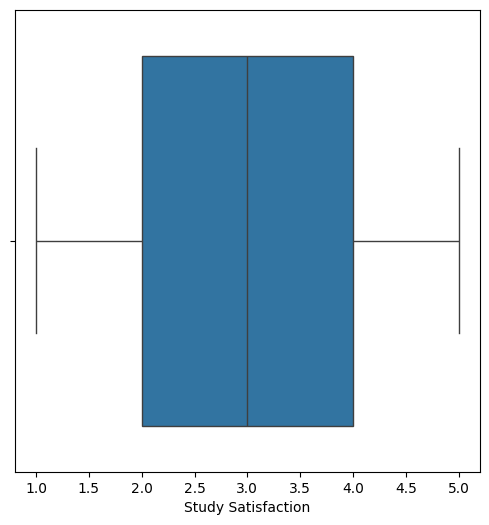

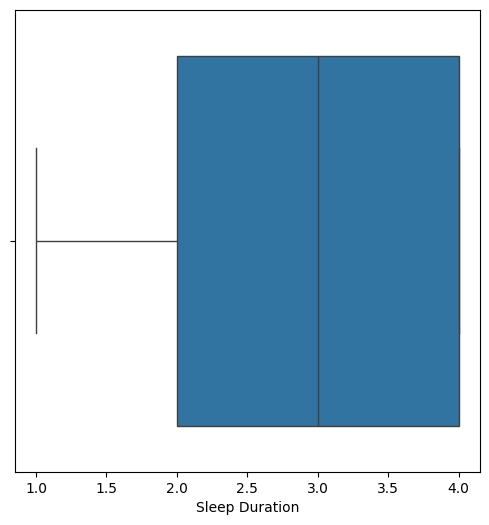

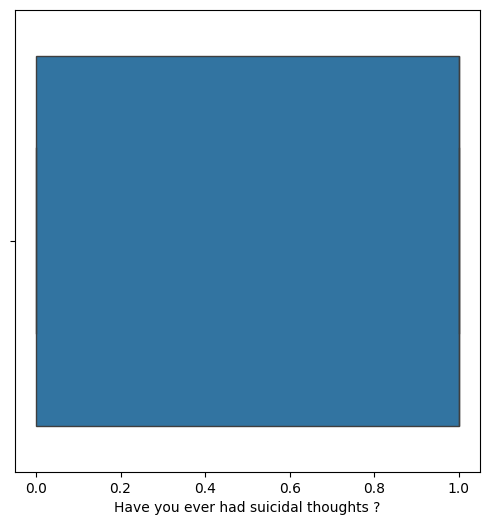

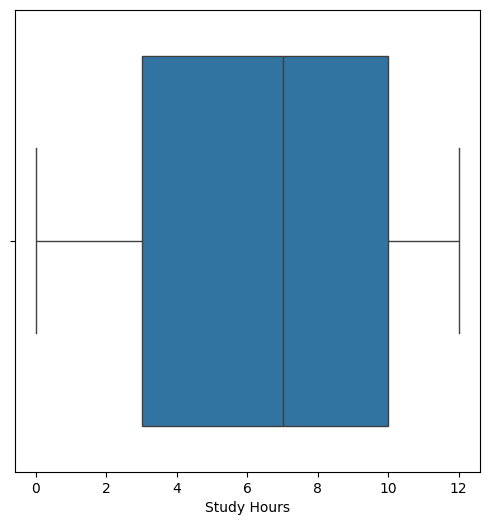

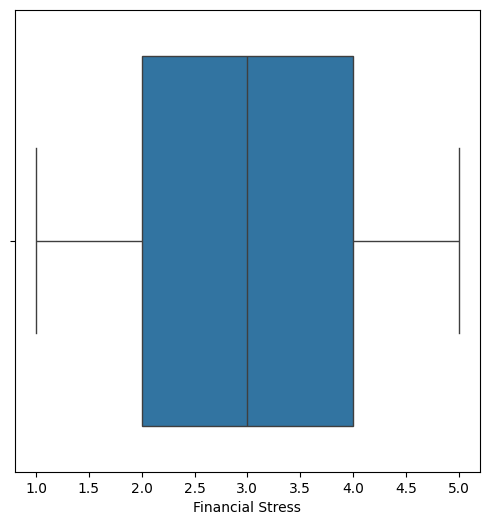

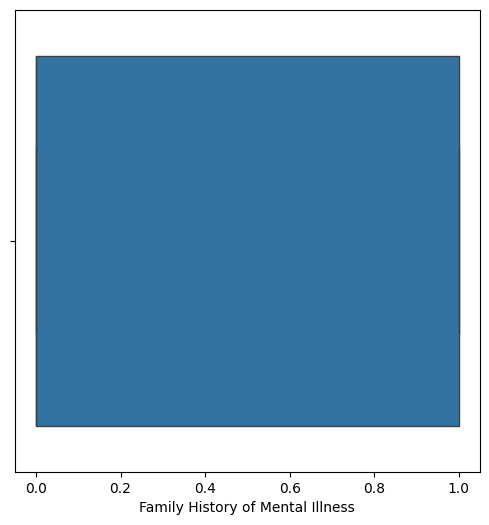

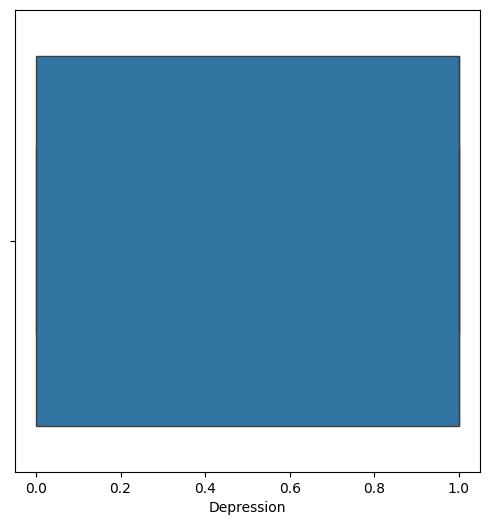

In [ ]:
for col in Num_data:
  plt.figure(figsize=(6,6))
  sns.boxplot(x=Num_data[col])

<Axes: xlabel='Depression', ylabel='Study Hours'>

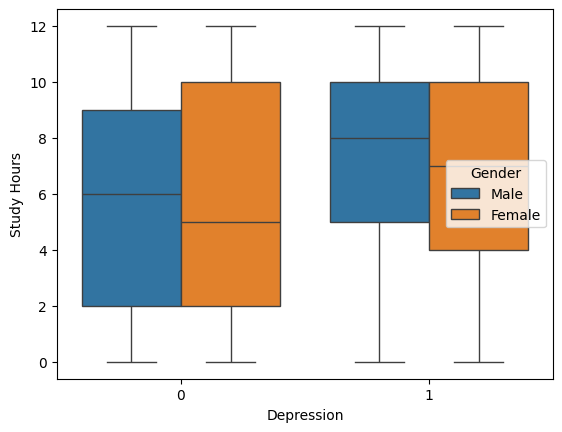

In [ ]:
sns.boxplot(x='Depression', y='Study Hours', hue='Gender', data=data)

<Axes: xlabel='Academic Pressure', ylabel='Study Hours'>

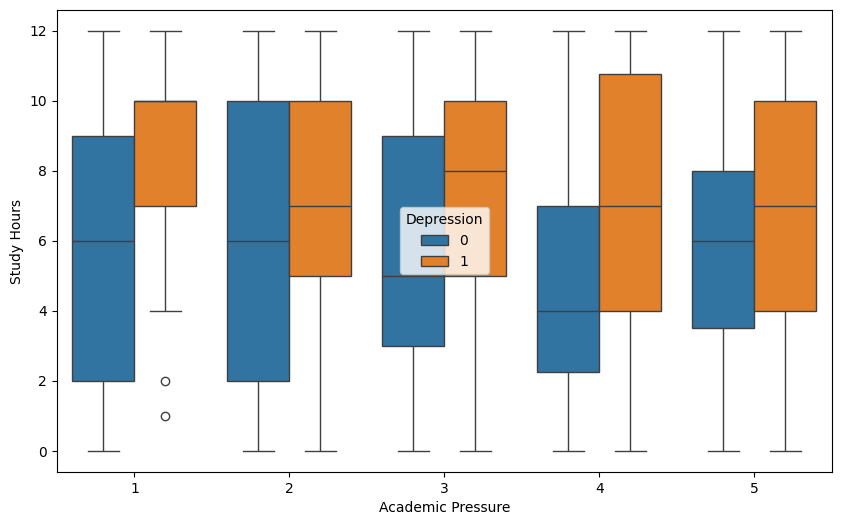

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Academic Pressure',
    y='Study Hours',
    hue='Depression',
    data=data
)

In [ ]:
gender_map={
    'Male':1,
    'Female':0
}
data['Gender']=data['Gender'].map(gender_map)


In [ ]:
dietary_map={
    'Unhealthy':0,
    'Moderate':1,
    'Healthy':2
}
data['Dietary Habits']=data['Dietary Habits'].map(dietary_map)

In [ ]:
data['Stress_index']=data['Academic Pressure']+data['Financial Stress']
data['Lifestyle_Score'] = data['Sleep Duration'] + data['Study Satisfaction'] + data['Dietary Habits']

# **Train and Test Split**

In [ ]:
X=data.drop('Depression',axis=1)
y=data['Depression']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# **Training and Testing Different Models**

In [ ]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Support Vector Classifier': SVC(kernel='rbf')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'CV Accuracy Mean': np.mean(cv_scores),
        'CV Accuracy Std': np.std(cv_scores)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                           Accuracy  Precision    Recall  F1 Score  \
Logistic Regression        0.980198   1.000000  0.961538  0.980392   
Random Forest              0.910891   0.938776  0.884615  0.910891   
Gradient Boosting          0.930693   0.909091  0.961538  0.934579   
Support Vector Classifier  0.950495   0.943396  0.961538  0.952381   

                           CV Accuracy Mean  CV Accuracy Std  
Logistic Regression                0.982531         0.010016  
Random Forest                      0.910309         0.021007  
Gradient Boosting                  0.935123         0.024316  
Support Vector Classifier          0.950123         0.013695  


# **Hyperparameter tuning for model**

---



In [ ]:


param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("After Hyperparamter tuning:\n")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

After Hyperparamter tuning:

Accuracy: 0.9900990099009901
Precision: 1.0
Recall: 0.9807692307692307
F1 Score: 0.9902912621359223


In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[49  0]
 [ 1 51]]


In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

pipeline.fit(X_train, y_train)

with open('depression_pipeline.pkl', 'wb') as file:
    pickle.dump(pipeline, file)